根据03_03,我们不应该直接用股价的SMA,本质是线性外推.RSI和SMA可能更适合用于百分比关系.我们是否可以加入交互项?

同时,根据价值投资的原则,是否可以加入年报的数据呢?根据四个季度的利润,能否解释一部分的股价呢?因为股票的价格应该是围绕市值的,其他的变量应该是影响波动.

我们先追求百分比变化,通过股价的百分比变化,找出金价,铜价等变化百分比,得到一个r,再用当天价格*(1+r)来得到股价.

此外,在模型中把今天的到的涨跌幅在作为一个新的因子,将y作为新的变量,看看涨幅是否具有延续性.

---

对于指数,我们采用百分比变化.而对于利率,其本身已是百分比,因此我们用Delta

In [1]:
from utils.common import *

In [2]:
data_set = pd.read_pickle('./src/pickle/Dataset.pkl')

In [3]:
X = data_set.X
Y = data_set.Y

In [4]:
display(X)

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [5]:
X_temp1 = X.drop(columns=['cn_10y_rate','us_10y_rate'])
X_temp2 = X[['cn_10y_rate','us_10y_rate']]

In [6]:
X_temp1_pct = X_temp1.pct_change()
X_temp2_delta = X_temp2.diff()

In [7]:
X_temp1_pct

,A_500,Dollar Index,brent,Copper Futures Price,Gold Futures Price
2012-05-09,NaN,NaN,NaN,NaN,NaN
2012-05-10,0.000166,0.000375,0.003128,0.008471,0.000878
2012-05-11,-0.006520,0.002122,0.002316,-0.011516,-0.007210
2012-05-14,-0.007351,0.003986,-0.015200,-0.025768,-0.014524
2012-05-15,0.000574,0.007692,0.005506,-0.010270,-0.002435
...,...,...,...,...,...
2026-07-17,-0.042617,0.000199,0.046535,-0.012141,0.006799
2026-07-20,0.008089,0.002382,0.023291,0.012131,-0.000598
2026-07-21,0.038608,0.001881,0.078860,0.033354,0.015161
2026-07-22,-0.006187,-0.000395,0.002877,-0.009004,0.018619


In [8]:
X_temp2_delta

,cn_10y_rate,us_10y_rate
2012-05-09,NaN,NaN
2012-05-10,-0.0127,0.02
2012-05-11,-0.0380,-0.05
2012-05-14,-0.0446,-0.06
2012-05-15,-0.0411,-0.02
...,...,...
2026-07-17,-0.0033,-0.02
2026-07-20,0.0049,0.05
2026-07-21,-0.0003,0.03
2026-07-22,-0.0153,0.04


In [9]:
X_temp = pd.concat([X_temp1_pct,X_temp2_delta],axis=1)

In [10]:
X_temp

,A_500,Dollar Index,brent,Copper Futures Price,Gold Futures Price,cn_10y_rate,us_10y_rate
2012-05-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-10,0.000166,0.000375,0.003128,0.008471,0.000878,-0.0127,0.02
2012-05-11,-0.006520,0.002122,0.002316,-0.011516,-0.007210,-0.0380,-0.05
2012-05-14,-0.007351,0.003986,-0.015200,-0.025768,-0.014524,-0.0446,-0.06
2012-05-15,0.000574,0.007692,0.005506,-0.010270,-0.002435,-0.0411,-0.02
...,...,...,...,...,...,...,...
2026-07-17,-0.042617,0.000199,0.046535,-0.012141,0.006799,-0.0033,-0.02
2026-07-20,0.008089,0.002382,0.023291,0.012131,-0.000598,0.0049,0.05
2026-07-21,0.038608,0.001881,0.078860,0.033354,0.015161,-0.0003,0.03
2026-07-22,-0.006187,-0.000395,0.002877,-0.009004,0.018619,-0.0153,0.04


In [11]:
X_temp = X_temp.dropna()

In [12]:
Y_pct = Y.pct_change()
Y_pct = Y_pct.dropna()
Y_pct

2012-05-10   -0.004673
2012-05-11   -0.014085
2012-05-14   -0.011905
2012-05-15   -0.002410
2012-05-16   -0.014493
                ...   
2026-07-17   -0.030427
2026-07-20    0.034908
2026-07-21    0.029302
2026-07-22    0.065872
2026-07-23    0.026708
Name: Zijin, Length: 3836, dtype: float64

In [13]:
X = X_temp
Y = Y_pct 

In [14]:
print(X.shape,Y.shape)

(3836, 7) (3836,)


In [15]:
#此处把数据上移,让今日数据预测明日的价格
Y = Y.shift(-1)
Y

2012-05-10   -0.014085
2012-05-11   -0.011905
2012-05-14   -0.002410
2012-05-15   -0.014493
2012-05-16    0.012255
                ...   
2026-07-17    0.034908
2026-07-20    0.029302
2026-07-21    0.065872
2026-07-22    0.026708
2026-07-23         NaN
Name: Zijin, Length: 3836, dtype: float64

In [16]:
Y = Y[:-1]
X = X[:-1]

In [17]:
X_train = X[:-500]
Y_train = Y[:-500]
X_test = X[-500:]
Y_test = Y[-500:]

RMSE： 0.024312560345062087
R²： 0.010729898506623425


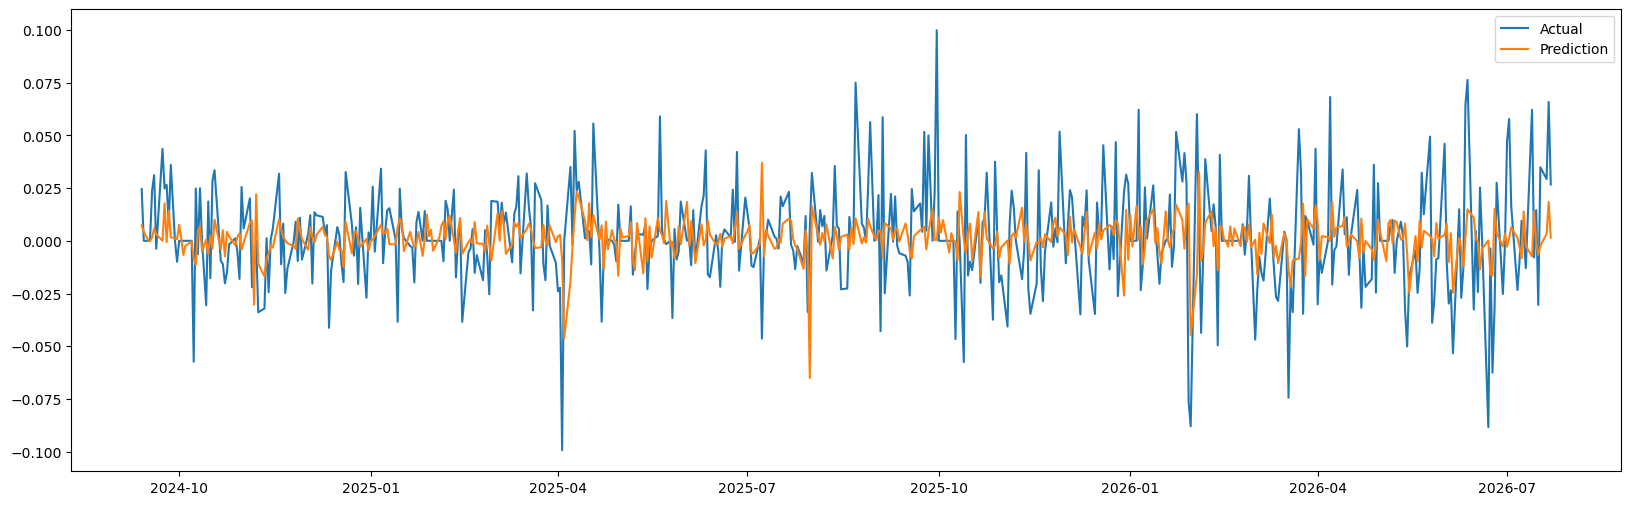

A_500                   0.000978
Dollar Index           -0.001217
brent                   0.000936
Copper Futures Price    0.003713
Gold Futures Price      0.002381
cn_10y_rate            -0.000048
us_10y_rate            -0.001368
dtype: float64

In [18]:
Lasso_test(X_train,Y_train,X_test,Y_test)

估计价格变化的是有问题的

RMSE： 0.021530257272600765
R²： 0.07784812646282457


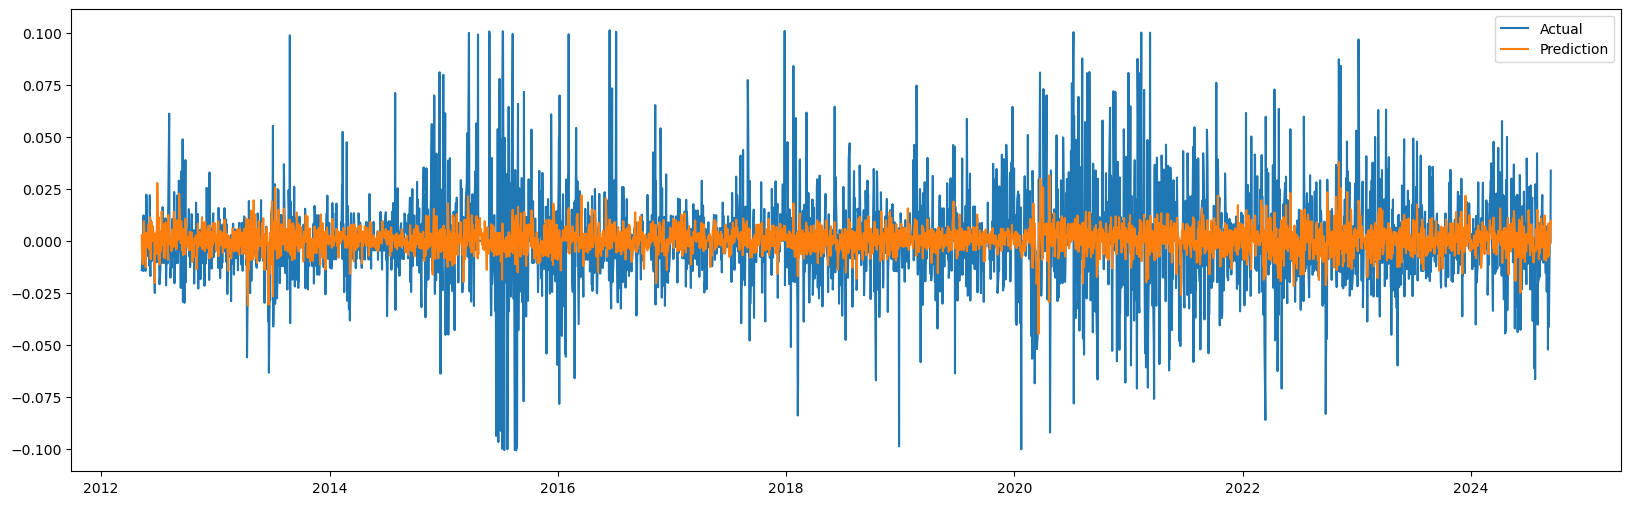

A_500                   0.000978
Dollar Index           -0.001217
brent                   0.000936
Copper Futures Price    0.003713
Gold Futures Price      0.002381
cn_10y_rate            -0.000048
us_10y_rate            -0.001368
dtype: float64

In [19]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
    ])

ts_split = TimeSeriesSplit(n_splits=5)

parameters = {
    'lasso__alpha': np.logspace(-5, 1, 1000)
}

grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)

grid_lasso.fit(X_train, Y_train)

Y_pred = grid_lasso.predict(X_train)
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred))
r2 = r2_score(Y_train, Y_pred)

print("RMSE：", rmse)
print("R²：", r2)
plt.figure(figsize=(20,6))
plt.plot(Y_train.index, Y_train, label='Actual')
plt.plot(Y_train.index, Y_pred, label='Prediction')
plt.legend()
plt.show()

coef = grid_lasso.best_estimator_.named_steps["lasso"].coef_
display(pd.Series(coef, index=X_train.columns))

短期的涨跌幅应该是无法预测的.至少从几个宏观因素上,根本无法解释剧烈的变化,预测非常保守.  
由于预测价格带有惯性, 因此R^2预测的更好.  
股价为趋势加上短期波动,而我们计算百分比变化,就是在计算短期波动,因此我们无法预测.

---

RSI一般分成4个区域,<30为超卖,30-50为偏低,50-70为偏高,>70为超买  
根据计量经济学,我们构造交互项,将RSI定性,以超卖为基准,看看不同情况下定性增加交互项,RSI情况与当前股价是否能解释一部分的波动?

In [20]:
X = data_set.X
Y = data_set.Y

In [21]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [22]:
Y

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

In [23]:
from utils.common import calculate_wilder_RSI

In [24]:
RSI = calculate_wilder_RSI(Y)
RSI

2012-05-09          NaN
2012-05-10     0.000000
2012-05-11     0.000000
2012-05-14     0.000000
2012-05-15     0.000000
                ...    
2026-07-17    53.260820
2026-07-20    61.955004
2026-07-21    67.933715
2026-07-22    77.411393
2026-07-23    80.312928
Name: Zijin, Length: 3837, dtype: float64

In [25]:
RSI= RSI.dropna()

In [26]:
RSI_type = pd.DataFrame()
RSI_type['low-mid'] = (RSI>30)&(RSI<=50) 

In [27]:
RSI_type['low-mid']

2012-05-10    False
2012-05-11    False
2012-05-14    False
2012-05-15    False
2012-05-16    False
              ...  
2026-07-17    False
2026-07-20    False
2026-07-21    False
2026-07-22    False
2026-07-23    False
Name: low-mid, Length: 3836, dtype: bool

In [28]:
RSI_type['mid-high'] = (RSI>50)&(RSI<=70)
RSI_type['high'] = RSI>70

In [29]:
RSI_type.astype(int)

,low-mid,mid-high,high
2012-05-10,0,0,0
2012-05-11,0,0,0
2012-05-14,0,0,0
2012-05-15,0,0,0
2012-05-16,0,0,0
...,...,...,...
2026-07-17,0,1,0
2026-07-20,0,1,0
2026-07-21,0,1,0
2026-07-22,0,0,1


此时加上交互项,要用今日的价格与RSI状态交互,然后得到系数

In [30]:
Y

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

In [31]:
Y_today = Y.copy()

In [32]:
Y_tomorrow = Y.copy().shift(-1)

In [33]:
Y_tomorrow

2012-05-09     4.26
2012-05-10     4.20
2012-05-11     4.15
2012-05-14     4.14
2012-05-15     4.08
              ...  
2026-07-17    29.35
2026-07-20    30.21
2026-07-21    32.20
2026-07-22    33.06
2026-07-23      NaN
Name: Zijin, Length: 3837, dtype: float64

这个today实际上是昨天的收盘价格,tomorrow是今天的收盘价格.我们应该错开一位.

In [34]:
RSI_interact = RSI_type.multiply(Y_today,axis=0)
RSI_interact

,low-mid,mid-high,high
2012-05-09,NaN,NaN,NaN
2012-05-10,0.0,0.0,0.0
2012-05-11,0.0,0.0,0.0
2012-05-14,0.0,0.0,0.0
2012-05-15,0.0,0.0,0.0
...,...,...,...
2026-07-17,0.0,28.36,0.0
2026-07-20,0.0,29.35,0.0
2026-07-21,0.0,30.21,0.0
2026-07-22,0.0,0.0,32.2


In [35]:
RSI_interact = RSI_interact.dropna()

In [36]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393
...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122


In [37]:
X_temp = pd.concat([X,RSI_interact],axis=1)

In [38]:
X_temp

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,low-mid,mid-high,high
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000,NaN,NaN,NaN
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474,0.0,0.0,0.0
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561,0.0,0.0,0.0
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736,0.0,0.0,0.0
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587,0.0,28.36,0.0
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,0.0,29.35,0.0
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967,0.0,30.21,0.0
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122,0.0,0.0,32.2


In [39]:
X_temp = X_temp.dropna()
X = X_temp

In [40]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,low-mid,mid-high,high
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474,0.0,0.0,0.0
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561,0.0,0.0,0.0
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736,0.0,0.0,0.0
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393,0.0,0.0,0.0
2012-05-16,971.928639,81.370003,3.3618,1.76,109.80,3.4780,963.920436,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587,0.0,28.36,0.0
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,0.0,29.35,0.0
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967,0.0,30.21,0.0
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122,0.0,0.0,32.2


In [41]:
Y = Y_tomorrow
Y = Y[1:]
Y

2012-05-10     4.20
2012-05-11     4.15
2012-05-14     4.14
2012-05-15     4.08
2012-05-16     4.13
              ...  
2026-07-17    29.35
2026-07-20    30.21
2026-07-21    32.20
2026-07-22    33.06
2026-07-23      NaN
Name: Zijin, Length: 3836, dtype: float64

In [42]:
X_train = X[X.index<='2024-9-10']
X_test = X[X.index>'2024-9-10']
Y_train = Y[X_train.index]
Y_test = Y[X_test.index]

跟03_03比,保证数据完全相同

In [43]:
X_test = X_test[:-1]
Y_test = Y_test[:-1]

RMSE： 3.25467430277513
R²： 0.8360820627888399


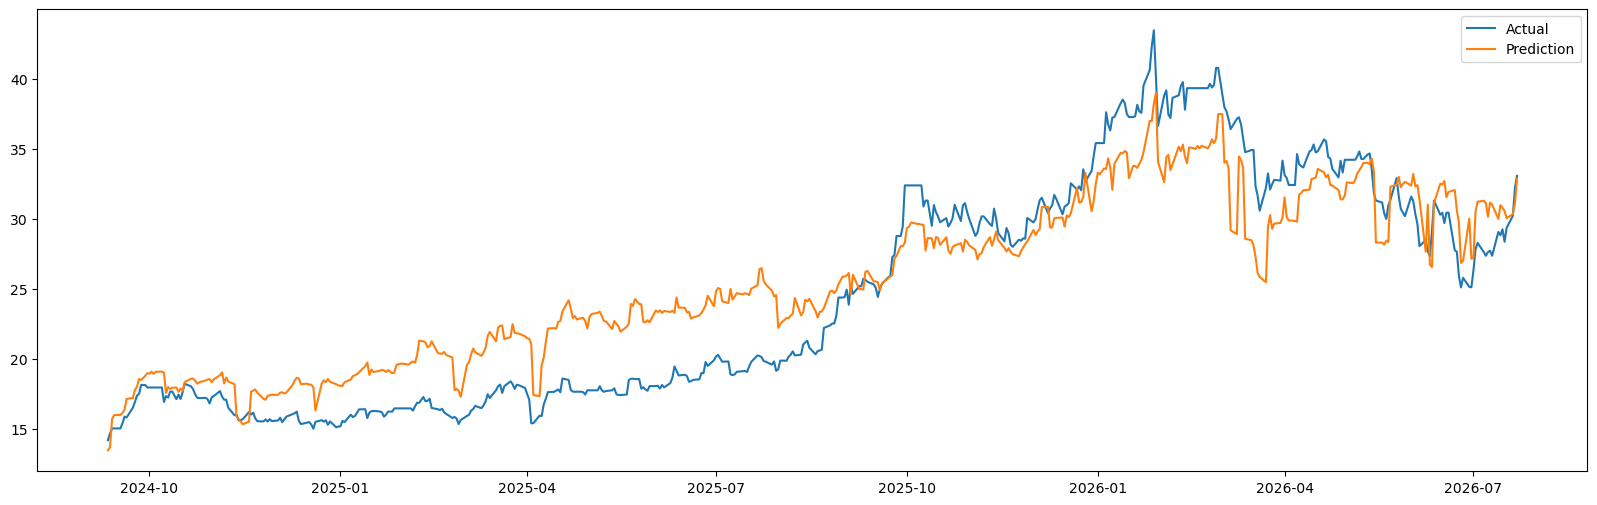

A_500                   1.068423
Dollar Index           -0.732851
cn_10y_rate            -0.969492
us_10y_rate             1.468791
brent                  -0.563965
Copper Futures Price    1.098285
Gold Futures Price      1.213896
low-mid                 0.460366
mid-high                0.534987
high                    0.510349
dtype: float64

In [44]:
Lasso_test(X_train,Y_train,X_test,Y_test)

这里设计错误了,如果省略了RSI<30的交互项,那么我们在模型设计中应该放入Pt,这样可能有会导致Y(t+1)≈Y(t)的现象发生.再试一次,看看他们的系数是多少,是否今天的股价解释了绝大部分的值.

In [45]:
RSI_type['low'] = RSI<=30
RSI_interact = RSI_type.multiply(Y_today,axis=0)
RSI_interact
 

,low-mid,mid-high,high,low
2012-05-09,NaN,NaN,NaN,NaN
2012-05-10,0.0,0.0,0.0,4.26
2012-05-11,0.0,0.0,0.0,4.2
2012-05-14,0.0,0.0,0.0,4.15
2012-05-15,0.0,0.0,0.0,4.14
...,...,...,...,...
2026-07-17,0.0,28.36,0.0,0.0
2026-07-20,0.0,29.35,0.0,0.0
2026-07-21,0.0,30.21,0.0,0.0
2026-07-22,0.0,0.0,32.2,0.0


In [46]:
RSI_interact = RSI_interact.dropna()

In [47]:
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price,low-mid,mid-high,high
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474,0.0,0.0,0.0
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561,0.0,0.0,0.0
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736,0.0,0.0,0.0
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393,0.0,0.0,0.0
2012-05-16,971.928639,81.370003,3.3618,1.76,109.80,3.4780,963.920436,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,2517.851587,0.0,28.36,0.0
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,2516.345719,0.0,29.35,0.0
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,2554.495967,0.0,30.21,0.0
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,2602.058122,0.0,0.0,32.2


In [48]:
X = X.iloc[:,0:6]
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175
2012-05-16,971.928639,81.370003,3.3618,1.76,109.80,3.4780
...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935


In [49]:
X = pd.concat([X,RSI_interact],axis=1)
X

,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,low-mid,mid-high,high,low
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,0.0,0.0,0.0,4.26
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,0.0,0.0,0.0,4.2
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,0.0,0.0,0.0,4.15
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,0.0,0.0,0.0,4.14
2012-05-16,971.928639,81.370003,3.3618,1.76,109.80,3.4780,0.0,0.0,0.0,4.08
...,...,...,...,...,...,...,...,...,...,...
2026-07-17,2024.406692,100.750000,1.7404,4.55,85.01,6.2650,0.0,28.36,0.0,0.0
2026-07-20,2040.782832,100.989998,1.7453,4.60,86.99,6.3410,0.0,29.35,0.0,0.0
2026-07-21,2119.573044,101.180000,1.7450,4.63,93.85,6.5525,0.0,30.21,0.0,0.0
2026-07-22,2106.458340,101.139999,1.7297,4.67,94.12,6.4935,0.0,0.0,32.2,0.0


In [50]:
X_train = X[X.index<='2024-9-10']
X_test = X[X.index>'2024-9-10']
Y_train = Y[X_train.index]
Y_test = Y[X_test.index]

In [51]:
X_test = X_test[:-1]
Y_test = Y_test[:-1]

RMSE： 0.6971402063074176
R²： 0.9924794141812596


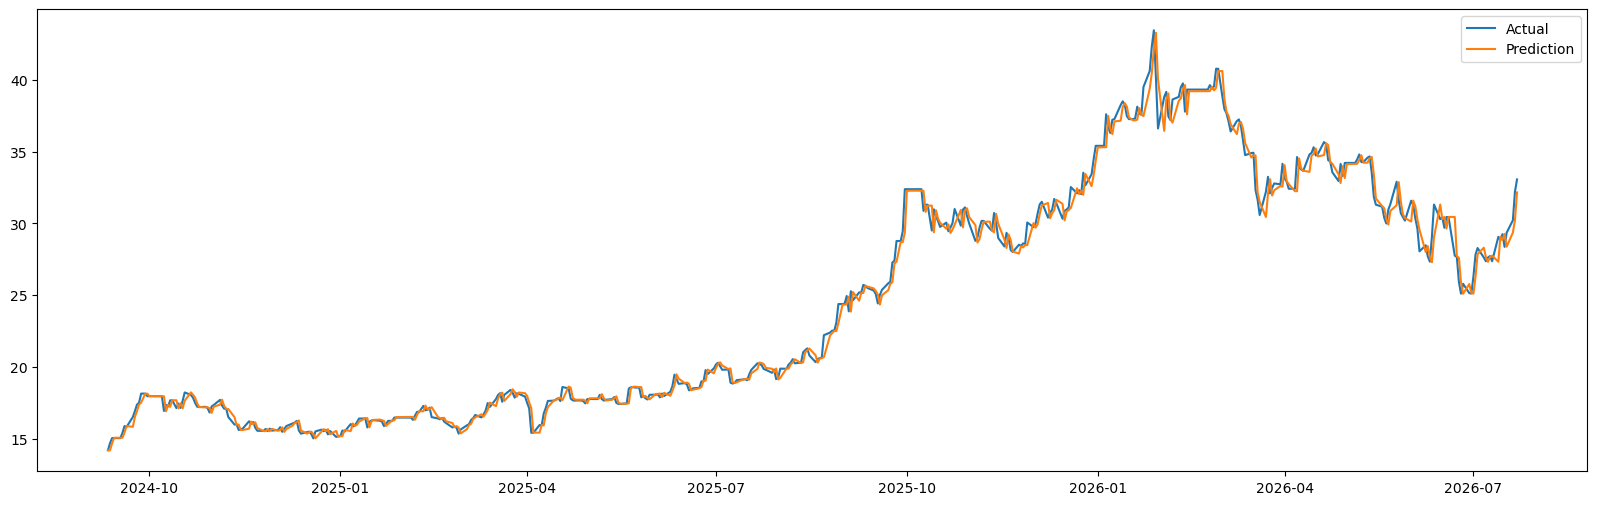

A_500                   0.006537
Dollar Index           -0.004595
cn_10y_rate            -0.018386
us_10y_rate             0.012864
brent                  -0.014273
Copper Futures Price    0.032642
low-mid                 3.670933
mid-high                3.927172
high                    2.918586
low                     2.102405
dtype: float64

In [52]:
Lasso_test(X_train,Y_train,X_test,Y_test)

与预测的一样,实际上就是把昨日的数据引入今天,至于宏观变量的影响因素就很小了.

假设我们只用昨日的股价和今天来预测,那么它的RMSE和R^2是多少?

In [54]:
Y_today

2012-05-09     4.28
2012-05-10     4.26
2012-05-11     4.20
2012-05-14     4.15
2012-05-15     4.14
              ...  
2026-07-17    28.36
2026-07-20    29.35
2026-07-21    30.21
2026-07-22    32.20
2026-07-23    33.06
Name: Zijin, Length: 3837, dtype: float64

In [55]:
Y_tomorrow

2012-05-09     4.26
2012-05-10     4.20
2012-05-11     4.15
2012-05-14     4.14
2012-05-15     4.08
              ...  
2026-07-17    29.35
2026-07-20    30.21
2026-07-21    32.20
2026-07-22    33.06
2026-07-23      NaN
Name: Zijin, Length: 3837, dtype: float64

In [56]:
Y_today = Y_today[:-1]
Y_tomorrow = Y_tomorrow[:-1]

RMSE： 0.29823157961256636
R²： 0.9985539026905746


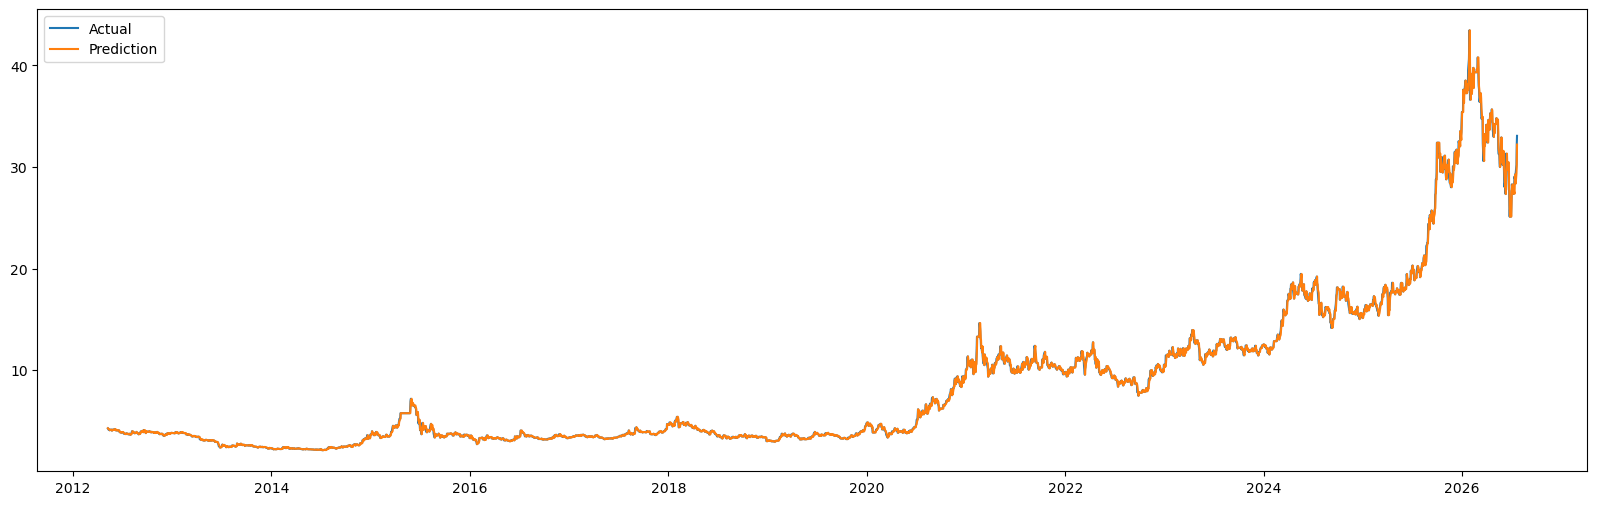

In [59]:
rmse = np.sqrt(mean_squared_error(Y_today, Y_tomorrow))
r2 = r2_score(Y_today, Y_tomorrow)

print("RMSE：", rmse)
print("R²：", r2)

plt.figure(figsize=(20,6))
plt.plot(Y_today.index,Y_tomorrow, label='Actual')
plt.plot(Y_today.index, Y_today, label='Prediction')
plt.legend()
plt.show()

加上RSI与价格后的交互项后,预测反而更差.对于股价预测来说,不能直接引入价格本身.

---

在测试集中,9月开始的行情,伴随着交易部大笔买入与评级,换手率上升.换手率或交易量上涨.能否根据换手率作为其中一个因子?  
换手率,融资融券数据,交易资金可以衡量市场暂时的情绪,如果我们用宏观数据得到的是真实数据,那么我们再乘以一个系数,这个系数乘以基准值得到的预测值,可不可以更好地衡量股票价格?

有些时候,股价先于金价反应,如果股价已经上涨了很多,那么黄金价格上涨,也难以继续上涨.